# ROGUE Results Evaluation

Builds two layers of summaries on top of the per-K `rogue_per_gep_K*.csv` outputs from `rogue_purity_evaluation.ipynb`:

1. **Per-GEP summaries** (sections 1–3): aggregate the per-(sample, GEP) ROGUE rows up to one number per GEP per K.
2. **Per-cell-type summaries** (sections 4–7): join with the GSEA NES tables to ask the cell-type question — *which labels are pure, which can be split further, which are stuck heterogeneous*.

**Inputs expected:**
- `ROGUE_DIR/rogue_per_gep_K{K}.csv` — from `rogue_purity_evaluation.ipynb` §5
- `ROGUE_DIR/rogue_celltype_audit.csv` — from `rogue_purity_evaluation.ipynb` §4
- `GSEA_DIR/NES_k{K}.csv` — from `gsea_celltype_annotation.ipynb`

In [1]:
import os
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns

try:
    from adjustText import adjust_text
    HAS_ADJUST_TEXT = True
except ImportError:
    HAS_ADJUST_TEXT = False


In [2]:
ROGUE_DIR = "rogue_purity_results"
OUT_DIR   = "rogue_purity_results"
GSEA_DIR  = "combined-hnc_k3-35_gsea_celltype_results"  # update if different

# Correlation-tree output directory  (from celltype_gated_correlation.ipynb).
# Should match the OUTPUT_DIR set in the correlation-tree notebook.
CORR_TREE_DIR = "combined-hnc_k3-35_corr-tree_kl-divergence"


## 1. Helper functions

In [3]:
def summarize_rogue_per_gep(df):
    """Aggregate per-(sample, GEP) ROGUE rows into one row per GEP."""
    summary = (df.groupby('cluster')
                 .agg(n_samples   =('sample',  'nunique'),
                      median_ROGUE=('ROGUE',   'median'),
                      mean_ROGUE  =('ROGUE',   'mean'),
                      min_ROGUE   =('ROGUE',   'min'),
                      max_ROGUE   =('ROGUE',   'max'),
                      total_cells =('n_cells', 'sum'))
                 .round(3)
                 .rename_axis('GEP')
                 .reset_index())
    return summary


def classify(row, persistence_threshold=3, merge_r_threshold=0.7):
    """Map one row of the cell-type summary table to a recommendation.

    Used by §8 via ``df.apply(lambda r: classify(r, ...), axis=1)``.
    """
    lab       = row.get('label_ROGUE')
    best      = row.get('best_GEP_ROGUE')
    pers      = row.get('best_consecutive_persistence')
    partner   = row.get('top_merge_partner')
    partner_R = row.get('top_merge_partner_R')

    partner_callable = (
        pd.notna(partner)
        and pd.notna(partner_R)
        and partner_R >= merge_r_threshold
    )
    partner_str = (f"{partner} (R={partner_R:.2f})"
                   if partner_callable else None)
    is_persistent = pd.notna(pers) and pers >= persistence_threshold

    if pd.isna(lab):
        return 'No §4 audit'
    if pd.isna(best):
        if partner_callable:
            return f'Never resolved — likely redundant with {partner_str}'
        return 'Never resolved by cNMF — investigate why'

    delta = best - lab
    if lab >= 0.9 and best >= 0.9:
        return ('Already pure & persistent'
                if is_persistent
                else 'Already pure but transient — verify')
    if best >= 0.9 and delta >= 0.10:
        return ('Splitting recovers substructure & persistent — keep going'
                if is_persistent
                else 'Splitting recovers substructure but transient — verify')
    if best < 0.75:
        if partner_callable:
            return f'Heterogeneous, may merge with {partner_str}'
        return 'Heterogeneous & unresolved — consider redefining label'
    if delta >= 0.05:
        return 'Modest gains from splitting'
    return 'Borderline — minimal benefit from splitting'

## 2. Discover per-K CSVs

In [4]:
files = sorted(
    [f for f in glob.glob(os.path.join(ROGUE_DIR, "rogue_per_gep_K*.csv"))
     if 'summary' not in f],
    key=lambda f: int(re.search(r'K(\d+)', f).group(1))
)
print(f"Found {len(files)} per-K CSVs")

# Read each per-K CSV once into a {K: DataFrame} cache;
# downstream cells (§3 and §4) reuse this dict instead of re-reading.
rogue_dfs_by_K = {
    int(re.search(r'K(\d+)', os.path.basename(f)).group(1)): pd.read_csv(f)
    for f in files
}

Found 33 per-K CSVs


## 3. Build per-K and combined summaries

In [5]:
all_summaries = []
for k in sorted(rogue_dfs_by_K):
    summary = summarize_rogue_per_gep(rogue_dfs_by_K[k])
    summary.insert(0, 'K', k)

    out_path = os.path.join(OUT_DIR, f"rogue_per_gep_K{k}_summary.csv")
    summary.drop(columns='K').to_csv(out_path, index=False)
    print(f"\nK={k}  →  {out_path}")
    print(summary.drop(columns='K').to_string(index=False))

    all_summaries.append(summary)


K=3  →  rogue_purity_results/rogue_per_gep_K3_summary.csv
 GEP  n_samples  median_ROGUE  mean_ROGUE  min_ROGUE  max_ROGUE  total_cells
   1         56         0.754       0.754      0.623      0.855        18670
   2         27         0.510       0.534      0.391      0.841         6412
   3         30         0.844       0.834      0.601      0.973         1048

K=4  →  rogue_purity_results/rogue_per_gep_K4_summary.csv
 GEP  n_samples  median_ROGUE  mean_ROGUE  min_ROGUE  max_ROGUE  total_cells
   1         56         0.763       0.761      0.640      0.874        18689
   2         28         0.527       0.541      0.398      0.779         5302
   3         29         0.880       0.842      0.642      0.973         1016
   4         13         0.708       0.725      0.546      0.870         1077

K=5  →  rogue_purity_results/rogue_per_gep_K5_summary.csv
 GEP  n_samples  median_ROGUE  mean_ROGUE  min_ROGUE  max_ROGUE  total_cells
   1         56         0.763       0.758      0.629 

In [6]:
combined = pd.concat(all_summaries, ignore_index=True)
combined_path = os.path.join(OUT_DIR, "rogue_per_gep_summary_allK.csv")
combined.to_csv(combined_path, index=False)
print(f"Combined summary → {combined_path}  ({len(combined)} rows)")

Combined summary → rogue_purity_results/rogue_per_gep_summary_allK.csv  (315 rows)


## 4. Build celltype-aware long table

Joins each (sample, GEP) ROGUE row to the top-NES cell type for that GEP at that K, so we can re-aggregate at cell-type level. Also loads the §4 label audit (label-level ROGUE) for use as a baseline.

**Optional:** uncomment the `MIN_TOP_NES` filter if you want to drop GEPs whose top cell-type assignment is weak (recommended at low K, where one catch-all GEP can dominate with a marginal NES).

In [7]:
# MIN_TOP_NES = 1.5   # set a value to gate on assignment strength; None to keep everything
MIN_TOP_NES = None

ct_long = []
for k in sorted(rogue_dfs_by_K):
    nes_path = os.path.join(GSEA_DIR, f"NES_k{k}.csv")
    if not os.path.exists(nes_path):
        print(f"Skipping K={k}: NES file missing at {nes_path}")
        continue
    nes = pd.read_csv(nes_path, index_col=0)
    nes.index = nes.index.astype(str)
    top_ct  = nes.idxmax(axis=1)
    top_nes = nes.max(axis=1)

    rogue = rogue_dfs_by_K[k].copy()  # copy so we don't mutate the cache
    rogue['cluster']  = rogue['cluster'].astype(str)
    rogue['celltype'] = rogue['cluster'].map(top_ct)
    rogue['top_NES']  = rogue['cluster'].map(top_nes)
    if MIN_TOP_NES is not None:
        rogue = rogue[rogue['top_NES'] >= MIN_TOP_NES]
    ct_long.append(rogue)

ct_long = pd.concat(ct_long, ignore_index=True)
ct_long.to_csv(os.path.join(OUT_DIR, "rogue_per_gep_with_celltype_allK.csv"), index=False)
print(f"ct_long: {ct_long.shape[0]:,} rows across K={sorted(ct_long['K'].unique())}")

ct_long: 6,211 rows across K=[np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35)]


In [8]:
# Aggregate to (K, celltype) level
ct_per_k = (ct_long.groupby(['K', 'celltype'])
                   .agg(n_GEPs       =('cluster', 'nunique'),
                        n_samples    =('sample',  'nunique'),
                        median_ROGUE =('ROGUE',   'median'),
                        max_ROGUE    =('ROGUE',   'max'),
                        total_cells  =('n_cells', 'sum'))
                   .reset_index())
ct_per_k.to_csv(os.path.join(OUT_DIR, "rogue_per_celltype_perK.csv"), index=False)

# §4 label ROGUE (per-celltype median across samples)
label_audit = pd.read_csv(os.path.join(ROGUE_DIR, "rogue_celltype_audit.csv"))
# Auto-detect celltype column (varies by compute_rogue version: 'cluster', 'global.cluster4', etc.)
ct_col_in_audit = next(c for c in label_audit.columns
                       if c not in ['sample', 'ROGUE', 'n_cells'])
print(f"Using '{ct_col_in_audit}' as celltype column in label audit")
label_summary = (label_audit.groupby(ct_col_in_audit)['ROGUE']
                            .median()
                            .rename('label_ROGUE'))
label_summary.index.name = 'celltype'   # standardize for downstream joins

print(f"ct_per_k: {ct_per_k.shape[0]} (K, celltype) rows")
print(f"          {ct_per_k['K'].nunique()} K values, {ct_per_k['celltype'].nunique()} celltypes assigned")
print(f"label_summary: {len(label_summary)} celltypes audited in §4")

Using 'cluster' as celltype column in label audit
ct_per_k: 224 (K, celltype) rows
          33 K values, 14 celltypes assigned
label_summary: 17 celltypes audited in §4


## 5. Per-celltype trajectory grid

One panel per cell type. Each panel shows:

- **Solid orange (median GEP)** — median ROGUE across (GEPs assigned to this celltype, samples) at each K
- **Dashed blue (best GEP)** — max ROGUE achieved by any GEP→celltype pairing at each K
- **Red dotted line** — the label's own ROGUE from §4 (constant across K, since it doesn't depend on cNMF)
- **Small numbers under markers** — number of GEPs assigned to this celltype at that K

**Reading the shapes:**
- Lines tracking the red flat at high values → already pure, do not split
- Blue line rising above red as K grows → splitting recovers substructure
- Lines plateau below the red → cNMF can't resolve this label
- 'Never top-assigned' → cNMF never picks this celltype as the strongest enrichment for any GEP

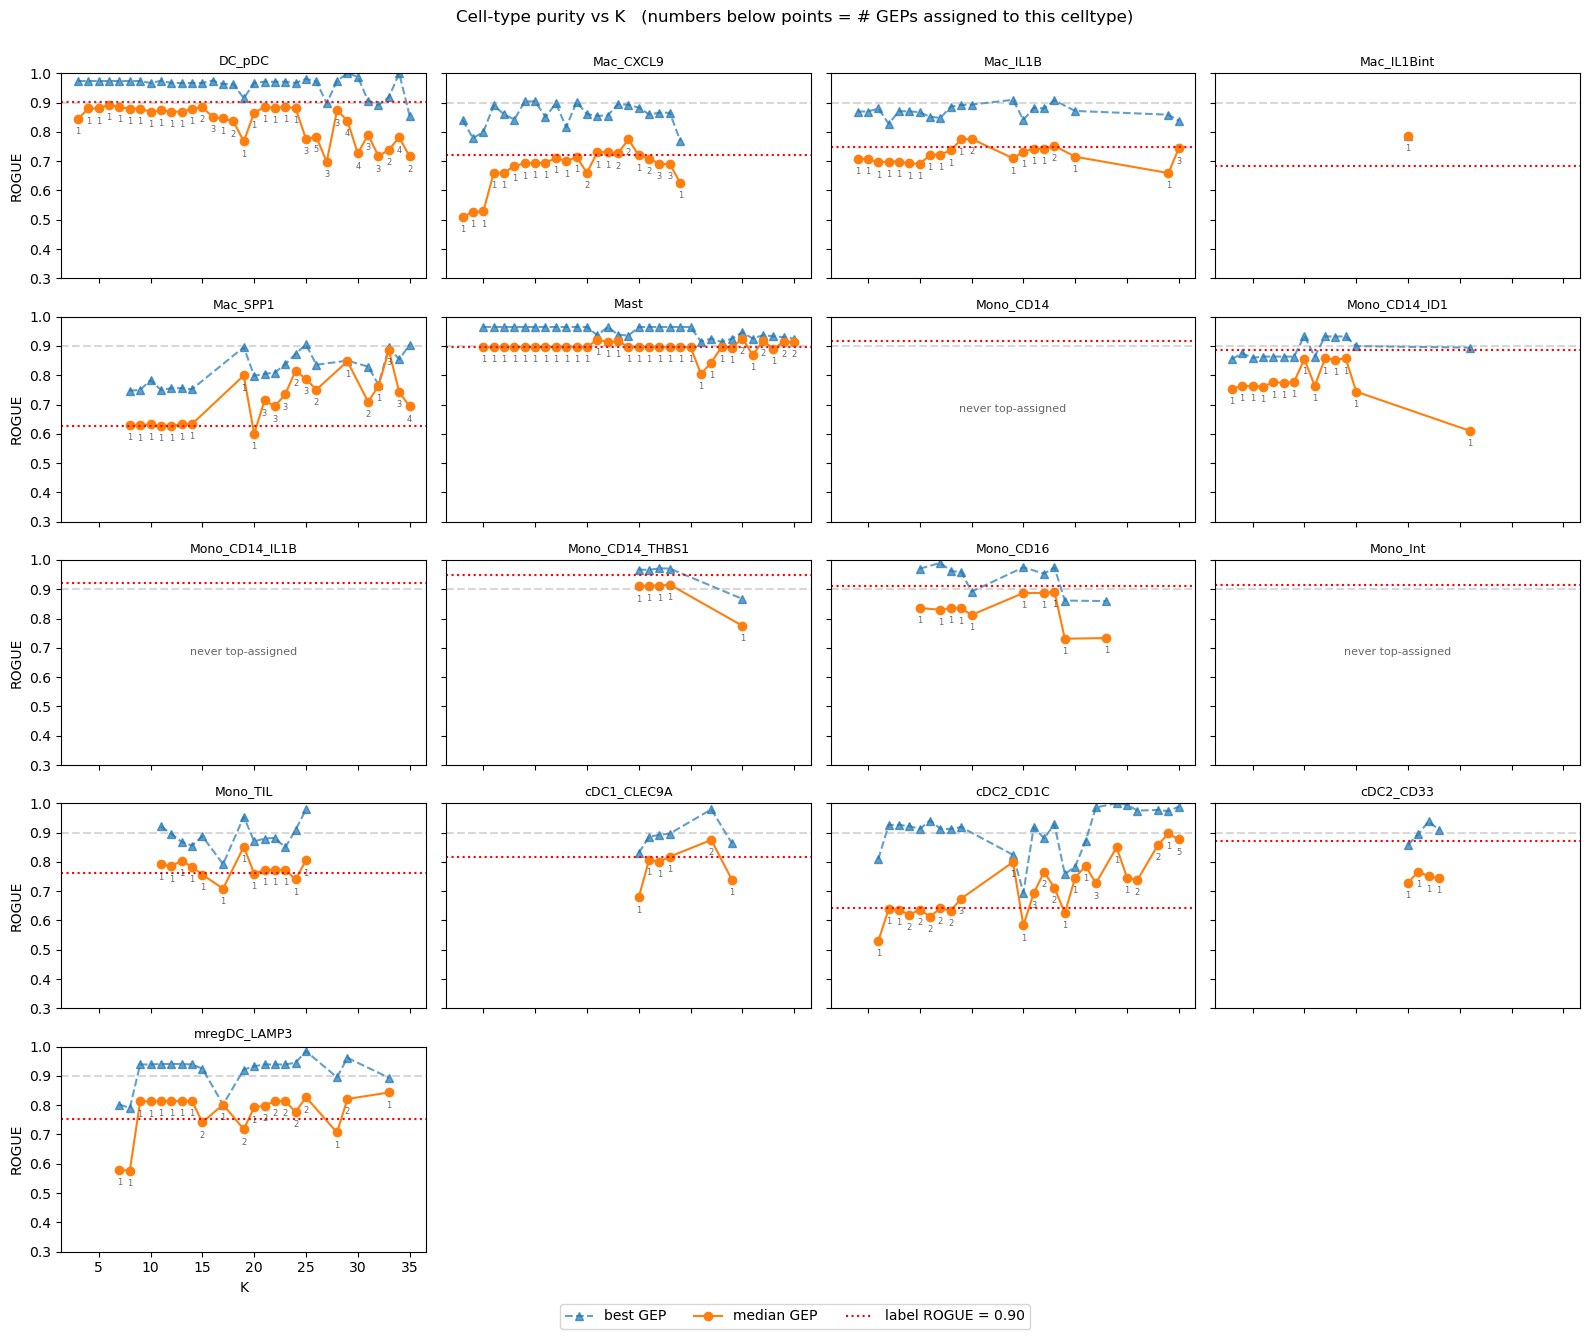

In [9]:
all_celltypes = sorted(label_summary.index) # all §4 labels
ncols = 4
nrows = (len(all_celltypes) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 2.6*nrows),
                         sharex=True, sharey=True)
axes = axes.flatten()

last_i = -1
for i, ct in enumerate(all_celltypes):
    ax = axes[i]
    last_i = i
    sub = ct_per_k[ct_per_k['celltype'] == ct].sort_values('K')
    label_r = label_summary.get(ct, np.nan)

    if not sub.empty:
        ax.plot(sub['K'], sub['max_ROGUE'],    marker='^', linestyle='--',
                alpha=0.7, label='best GEP', color='C0')
        ax.plot(sub['K'], sub['median_ROGUE'], marker='o',
                label='median GEP', color='C1')
        for _, row in sub.iterrows():
            ax.annotate(int(row['n_GEPs']), (row['K'], row['median_ROGUE']),
                        xytext=(0, -11), textcoords='offset points',
                        fontsize=6, ha='center', alpha=0.6)
    else:
        ax.text(0.5, 0.55, 'never top-assigned', ha='center', va='center',
                transform=ax.transAxes, fontsize=8, alpha=0.6)

    if not pd.isna(label_r):
        ax.axhline(label_r, color='red', linestyle=':',
                   label=f'label ROGUE = {label_r:.2f}')
    ax.axhline(0.9, color='gray', linestyle='--', alpha=0.3)
    ax.set_title(ct, fontsize=9)
    ax.set_ylim(0.3, 1.0)
    if i % ncols == 0: ax.set_ylabel('ROGUE')
    if i // ncols == nrows - 1: ax.set_xlabel('K')

for j in range(last_i + 1, len(axes)):
    axes[j].set_visible(False)

handles, labels_ = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.02))
plt.suptitle('Cell-type purity vs K   (numbers below points = # GEPs assigned to this celltype)',
             y=1.00)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "celltype_purity_trajectory.png"),
            dpi=150, bbox_inches='tight')
plt.show()

## 6. Decomposability scatter

Condenses each trajectory into one (label_ROGUE, best_GEP_ROGUE) point.

- **Above the diagonal** — cNMF found extra purity inside the label (“splitting recovers substructure”)
- **On the diagonal** — the label is already as pure as anything cNMF can produce for it
- **Bottom-left, near diagonal** — heterogeneous label, and cNMF can’t resolve it either
- **Upper-right** — already pure (no need to split)
- **× markers along the bottom** — celltypes never top-assigned by any GEP at any K

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


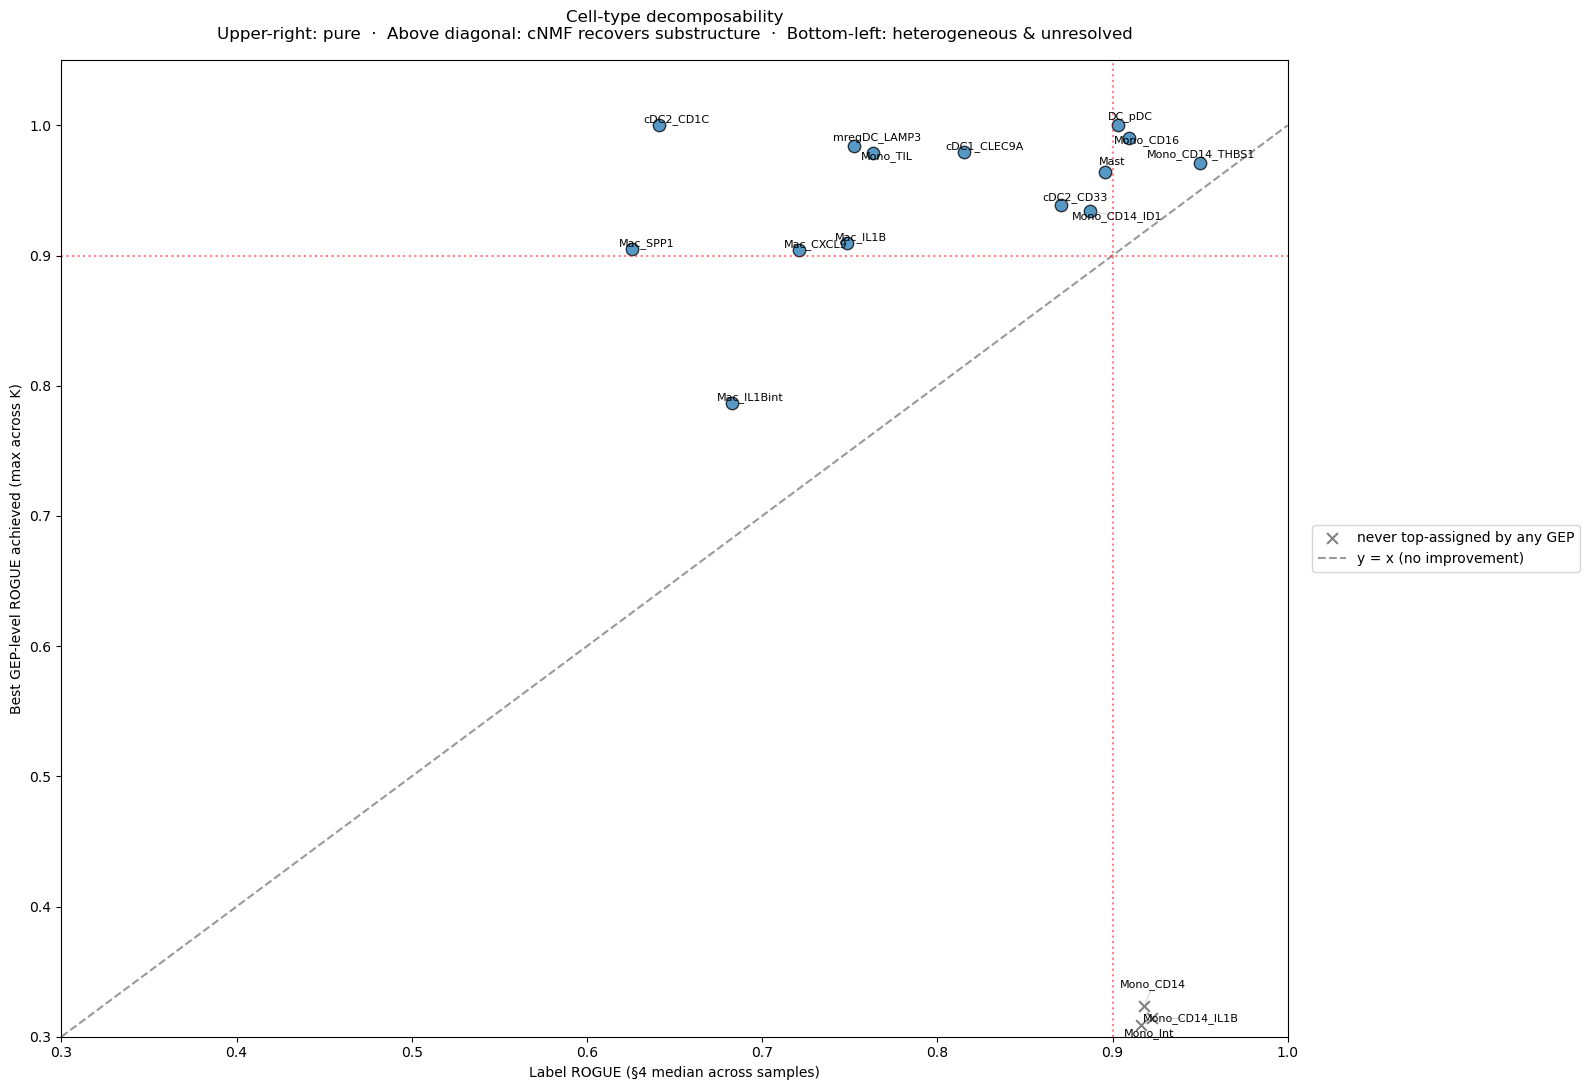

In [10]:
ct_best = (ct_per_k.groupby('celltype')
                   .agg(best_GEP_ROGUE   =('max_ROGUE',    'max'),
                        best_median_ROGUE=('median_ROGUE', 'max'),
                        max_n_GEPs       =('n_GEPs',       'max'),
                        K_at_best        =('max_ROGUE',
                                           lambda s: ct_per_k.loc[s.idxmax(), 'K']))
                   .reset_index())

# Bring in label_ROGUE via explicit merge on a known column name
ct_best = ct_best.merge(label_summary.reset_index(), on='celltype', how='outer')

# Tiny y-jitter on the 'never top-assigned' baseline so points (and their
# labels) don't pile up at identical xy when two cells share a label_ROGUE.
covered = ct_best['best_GEP_ROGUE'].notna()
rng = np.random.default_rng(0)
uncov_y = 0.32 + rng.uniform(-0.012, 0.012, (~covered).sum())

fig, ax = plt.subplots(figsize=(16, 11))
ax.scatter(ct_best.loc[covered, 'label_ROGUE'],
           ct_best.loc[covered, 'best_GEP_ROGUE'],
           s=80, edgecolor='black', alpha=0.75)
ax.scatter(ct_best.loc[~covered, 'label_ROGUE'],
           uncov_y,
           s=60, marker='x', color='gray',
           label='never top-assigned by any GEP')

# Collect labels as Text objects so adjustText can reposition them.
# Use the (jittered) baseline for uncovered points so the label sits next to its marker.
texts = []
uncov_iter = iter(uncov_y)
for _, row in ct_best.iterrows():
    y = row['best_GEP_ROGUE'] if pd.notna(row['best_GEP_ROGUE']) else next(uncov_iter)
    texts.append(ax.text(row['label_ROGUE'], y, row['celltype'], fontsize=8))

# Push overlapping labels apart and draw thin leader lines back to the points.
# `shrinkA=5` keeps the leader from striking through the text (silences the
# FancyArrowPatch fallback warning).
if HAS_ADJUST_TEXT:
    adjust_text(
        texts, ax=ax,
        arrowprops=dict(arrowstyle='-', color='gray',
                        alpha=0.5, lw=0.5, shrinkA=5),
        expand_points=(1.6, 1.8),
        expand_text=(1.4, 1.6),
        force_text=(0.6, 0.9),
        force_points=(0.4, 0.6),
    )
else:
    print("Tip: `pip install adjustText` to automatically separate overlapping labels.")

xs = np.linspace(0.3, 1.0, 50)
ax.plot(xs, xs, 'k--', alpha=0.4, label='y = x (no improvement)')
ax.axhline(0.9, color='red', linestyle=':', alpha=0.5)
ax.axvline(0.9, color='red', linestyle=':', alpha=0.5)

# Headroom above 1.0 + title `pad` keeps labels of pure cells off the title.
ax.set_xlabel('Label ROGUE (§4 median across samples)')
ax.set_ylabel('Best GEP-level ROGUE achieved (max across K)')
ax.set_xlim(0.3, 1.0)
ax.set_ylim(0.3, 1.05)
ax.set_title(
    'Cell-type decomposability\n'
    'Upper-right: pure  ·  Above diagonal: cNMF recovers substructure  ·  '
    'Bottom-left: heterogeneous & unresolved',
    pad=15,
)
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5),
          borderaxespad=0., frameon=True)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "celltype_decomposability_scatter.png"),
            dpi=150, bbox_inches='tight')
plt.show()

## 7. Load correlation-tree outputs

Pulls in the four CSVs written by `celltype_gated_correlation.ipynb` so the
persistence-aware half of §8 can mix purity (ROGUE) with persistence
(lineage span across K).

**Inputs expected (under `CORR_TREE_DIR`):**
- `gep_persistence.csv` — per-(K, GEP): `lineage_id`, `lineage_consecutive_span`, `lineage_size`, `lineage_dominant_celltype`
- `lineage_persistence.csv` — per-lineage: `consecutive_span`, `k_span`, `n_nodes`, `dominant_celltype`, `celltype_purity`
- `joint_granularity_summary.csv` — per-celltype: `emerges_at_K`, `best_consecutive_persistence`, `top_merge_partner`, `top_merge_partner_R`
- `merge_candidates.csv` — pairs ranked by NES redundancy

If any file is missing, the persistence-aware refinement in §8 is skipped
(graceful no-op); the base recommendations still run.


In [11]:
HAS_CORR_TREE        = False
gep_persistence       = None
lineage_persistence   = None
joint_granularity     = None
merge_candidates_corr = None

required = {
    'gep_persistence':       'gep_persistence.csv',
    'lineage_persistence':   'lineage_persistence.csv',
    'joint_granularity':     'joint_granularity_summary.csv',
    'merge_candidates_corr': 'merge_candidates.csv',
}

if not os.path.isdir(CORR_TREE_DIR):
    print(f"CORR_TREE_DIR not found: {CORR_TREE_DIR}")
    print("Persistence-aware refinement in §8 will be skipped.")
else:
    paths   = {k: os.path.join(CORR_TREE_DIR, fname) for k, fname in required.items()}
    missing = [(k, p) for k, p in paths.items() if not os.path.exists(p)]
    if missing:
        print(f"CORR_TREE_DIR found but these files are missing:")
        for k, p in missing:
            print(f"  {k:25s} → {p}")
        print("Persistence-aware refinement in §8 will be skipped.")
    else:
        gep_persistence       = pd.read_csv(paths['gep_persistence'])
        lineage_persistence   = pd.read_csv(paths['lineage_persistence'])
        joint_granularity     = pd.read_csv(paths['joint_granularity'])
        merge_candidates_corr = pd.read_csv(paths['merge_candidates_corr'])

        # Standardize join keys: cluster ↔ gep are both string IDs of GEPs.
        gep_persistence['gep'] = gep_persistence['gep'].astype(str)
        gep_persistence['k']   = gep_persistence['k'].astype(int)

        HAS_CORR_TREE = True
        print(f"Loaded correlation-tree outputs from: {CORR_TREE_DIR}")
        print(f"  gep_persistence:       {gep_persistence.shape}     "
              f"({gep_persistence['lineage_id'].nunique()} lineages)")
        print(f"  lineage_persistence:   {lineage_persistence.shape}")
        print(f"  joint_granularity:     {joint_granularity.shape}")
        print(f"  merge_candidates_corr: {merge_candidates_corr.shape}")


Loaded correlation-tree outputs from: combined-hnc_k3-35_corr-tree_kl-divergence
  gep_persistence:       (627, 8)     (17 lineages)
  lineage_persistence:   (17, 8)
  joint_granularity:     (17, 5)
  merge_candidates_corr: (136, 5)


## 8. Recommendation table

Turns the scatter geometry into one of six explicit recommendations per cell type. mixing in two extra signals:
- **`best_consecutive_persistence`** — splits each ROGUE-based call into a *persistent* vs *transient* version. A pure GEP that survives across many K values is a far stronger signal than one that pops up at a single K and disappears.
- **`top_merge_partner` / `top_merge_partner_R`** — when a label is heterogeneous *or* never resolved by cNMF, name the most-similar label so the suggestion is actionable.

**categories:**
- *Already pure & persistent* — strong signal; use confidently
- *Already pure but transient* — single-K artifact suspected; verify before using
- *Splitting recovers substructure & persistent* — real sub-states; keep K high
- *Splitting recovers substructure but transient* — verify the sub-state is reproducible
- *Heterogeneous, may merge with X (R=…)* — concrete merge target instead of generic "redefine"
- *Never resolved, likely redundant with X (R=…)* — the redundancy partner explains the absence
- *Modest gains from splitting*, *Borderline*, *No §4 audit* — unchanged from base classifier

Two thresholds gate the persistence and merge calls; tune to taste. The augmented per-celltype table is saved to `celltype_recommendations.csv`.

In [12]:
if not HAS_CORR_TREE:
    print("Error: correlation-tree outputs not loaded.")
else:
    # Tunable thresholds
    PERSISTENCE_THRESHOLD = 3    # consecutive K runs to count as "persistent"
    MERGE_R_THRESHOLD     = 0.7  # median R above which the merge partner is callable

    print(f"PERSISTENCE_THRESHOLD = {PERSISTENCE_THRESHOLD}  "
          f"(consecutive_span ≥ this → 'persistent')")
    print(f"MERGE_R_THRESHOLD     = {MERGE_R_THRESHOLD}  "
          f"(top_merge_partner_R ≥ this → name the partner in recommendation)")

    # Pull persistence + merge-partner info from the corr tree onto ct_best
    jg_cols = ['celltype', 'emerges_at_K', 'best_consecutive_persistence',
               'top_merge_partner', 'top_merge_partner_R']
    ct_best_p = ct_best.merge(joint_granularity[jg_cols], on='celltype', how='left')

    ct_best_p['recommendation'] = ct_best_p.apply(
        lambda row: classify(row, PERSISTENCE_THRESHOLD, MERGE_R_THRESHOLD),
        axis=1,
    )

    # Order: by category, then strongest within category
    ct_best_p_sorted = ct_best_p.sort_values(
        ['recommendation', 'best_GEP_ROGUE'],
        ascending=[True, False]
    )
    out_path = os.path.join(OUT_DIR, 'celltype_recommendations.csv')
    ct_best_p_sorted.round(3).to_csv(out_path, index=False)
    print(f"Saved → {out_path}")

    cols_to_show = ['celltype', 'label_ROGUE', 'best_GEP_ROGUE',
                    'best_consecutive_persistence',
                    'top_merge_partner', 'top_merge_partner_R',
                    'recommendation']
    print("\nPersistence-aware recommendations:")
    print("=" * 110)
    print(ct_best_p_sorted[cols_to_show].round(3).to_string(index=False))

    print("\nCategory counts:")
    print(ct_best_p_sorted['recommendation'].value_counts().to_string())

PERSISTENCE_THRESHOLD = 3  (consecutive_span ≥ this → 'persistent')
MERGE_R_THRESHOLD     = 0.7  (top_merge_partner_R ≥ this → name the partner in recommendation)
Saved → rogue_purity_results/celltype_recommendations.csv

Persistence-aware recommendations:
       celltype  label_ROGUE  best_GEP_ROGUE  best_consecutive_persistence top_merge_partner  top_merge_partner_R                                                  recommendation
         DC_pDC        0.903           1.000                           NaN              Mast                0.776                             Already pure but transient — verify
      Mono_CD16        0.909           0.990                           NaN          Mono_Int                0.751                             Already pure but transient — verify
Mono_CD14_THBS1        0.950           0.971                           NaN     Mono_CD14_ID1                0.930                             Already pure but transient — verify
  Mono_CD14_ID1        0.887   

## 9. Visualizations

In [13]:
path = os.path.join(OUT_DIR, "celltype_recommendations.csv")
rec  = pd.read_csv(path)

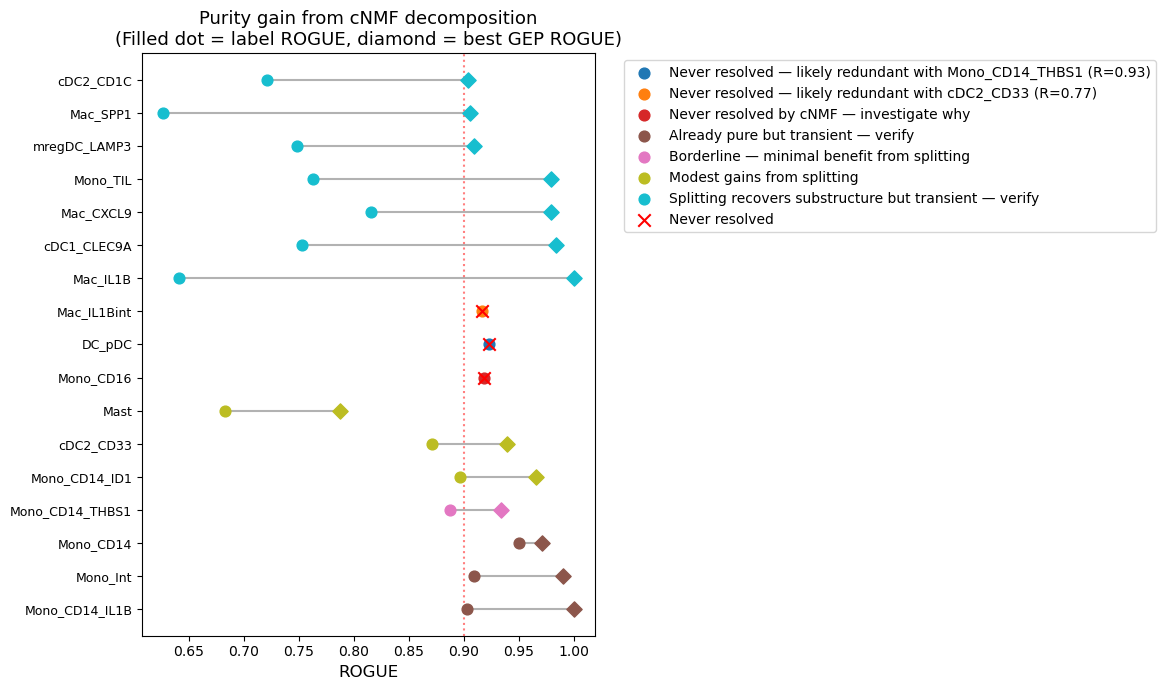

In [14]:
plot_df = rec.copy()
plot_df['best_display'] = plot_df['best_GEP_ROGUE'].fillna(plot_df['label_ROGUE'])
plot_df['gain'] = plot_df['best_display'] - plot_df['label_ROGUE']
plot_df = plot_df.sort_values('gain', ascending=True)

# Color map for recommendation categories
categories = plot_df['recommendation'].unique()
colors = plt.cm.tab10(np.linspace(0, 1, len(categories)))
color_dict = dict(zip(categories, colors))

fig, ax = plt.subplots(figsize=(12, 7))

for idx, row in plot_df.iterrows():
    y = idx
    lab = row['label_ROGUE']
    best = row['best_display']
    cat = row['recommendation']

    # Draw stem from label to best
    ax.plot([lab, best], [y, y], color='gray', alpha=0.6, linewidth=1.5)
    # Mark label value
    ax.scatter(lab, y, color=color_dict[cat], s=60, zorder=3, label=cat)
    # Mark best value (if different)
    if abs(best - lab) > 0.01:
        ax.scatter(best, y, color=color_dict[cat], marker='D', s=60, zorder=3)

# Special marking for never‑resolved (best missing)
never_resolved = plot_df['best_GEP_ROGUE'].isna()
for idx, row in plot_df[never_resolved].iterrows():
    ax.scatter(row['label_ROGUE'], idx, marker='x', color='red', s=80, zorder=4,
               label='Never resolved' if idx == never_resolved.idxmax() else "")

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))  # remove duplicates
ax.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels(plot_df['celltype'].values, fontsize=9)
ax.set_xlabel('ROGUE', fontsize=12)
ax.set_title('Purity gain from cNMF decomposition\n(Filled dot = label ROGUE, diamond = best GEP ROGUE)', fontsize=13)
ax.axvline(0.9, color='red', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()